In [187]:
import logging
import os
import sys
import traceback
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import torch

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import sys 
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader
import yaml

In [30]:
with initialize(config_path="../../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

In [125]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [31]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Read old and new data

In [188]:
adata_old_experiments = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k.h5ad")
adata_loop2.obs["cell_type"] = "Unannotated"

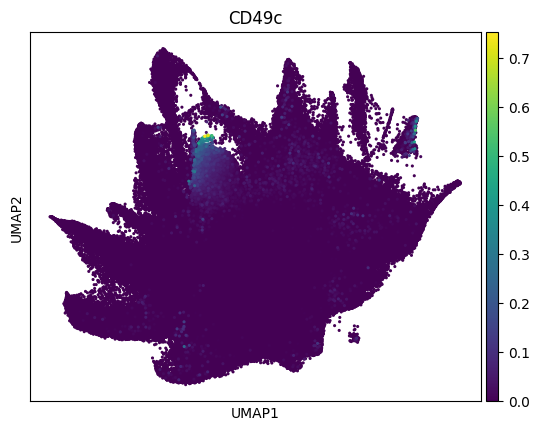

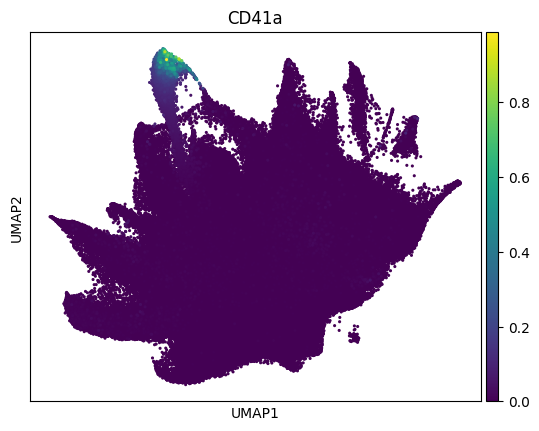

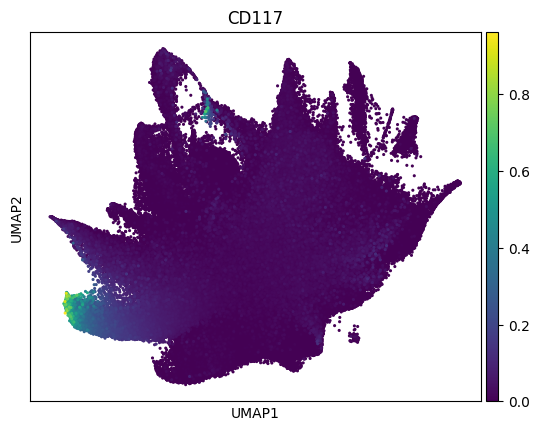

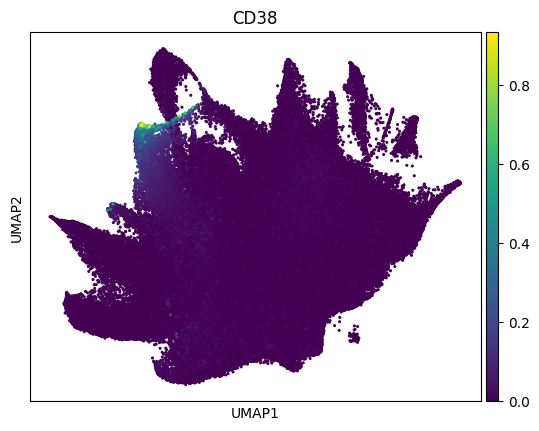

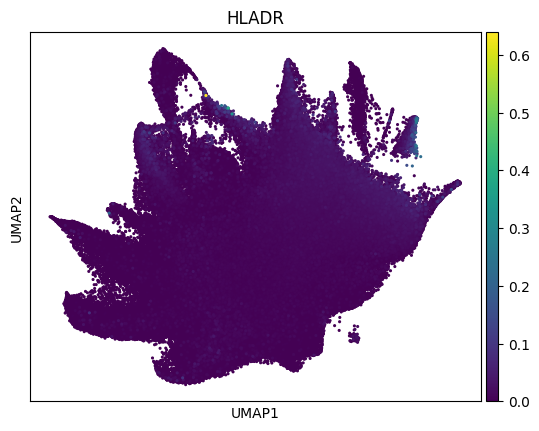

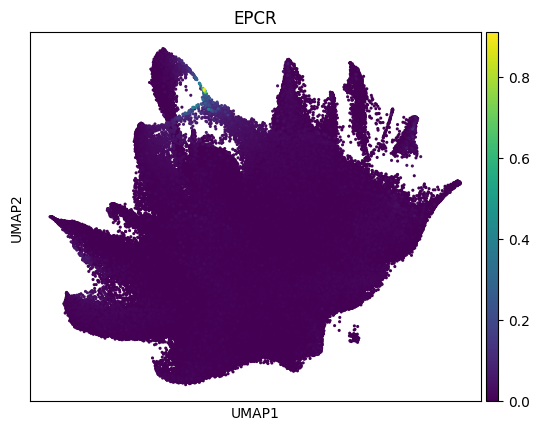

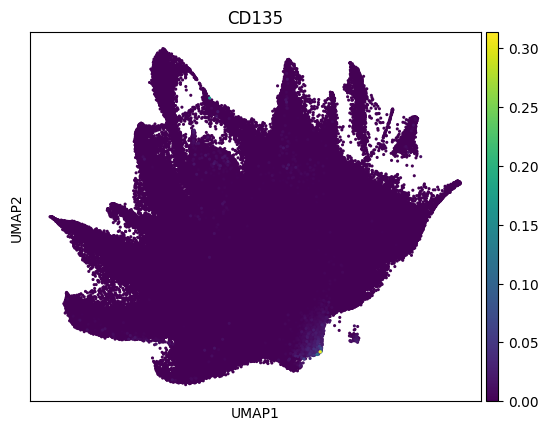

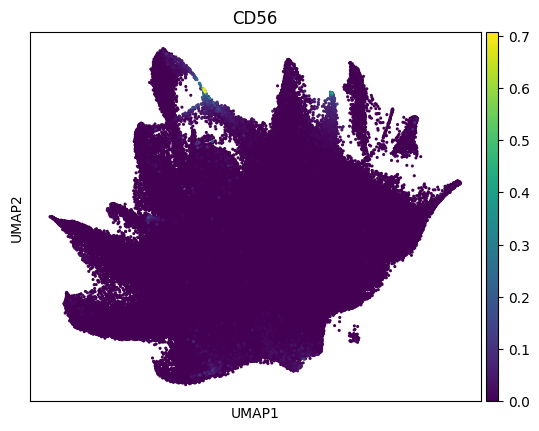

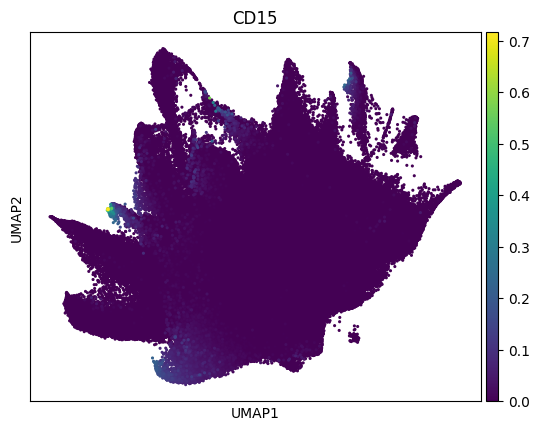

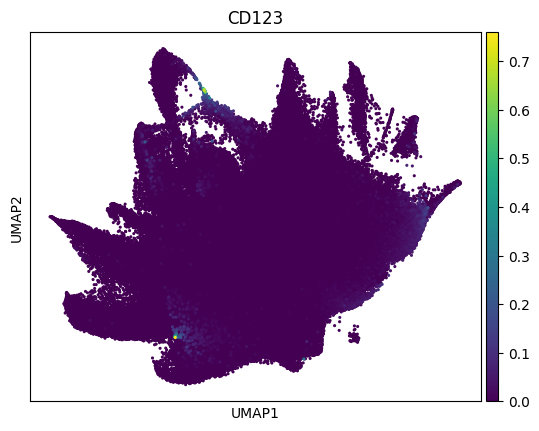

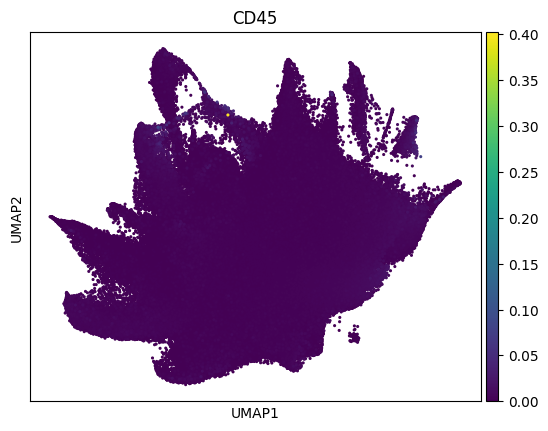

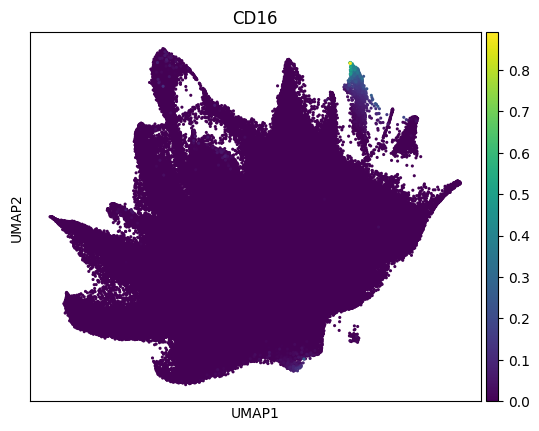

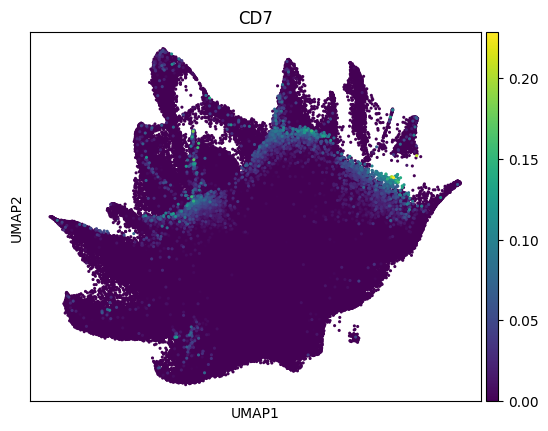

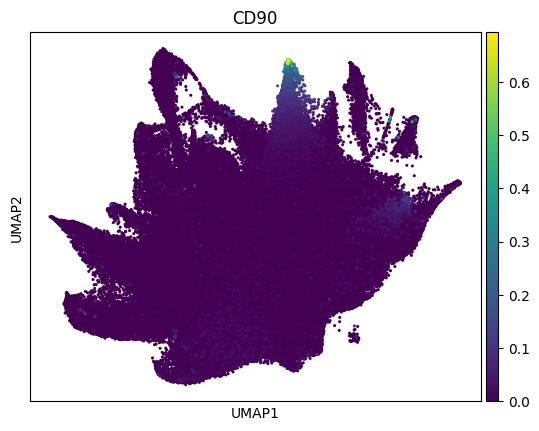

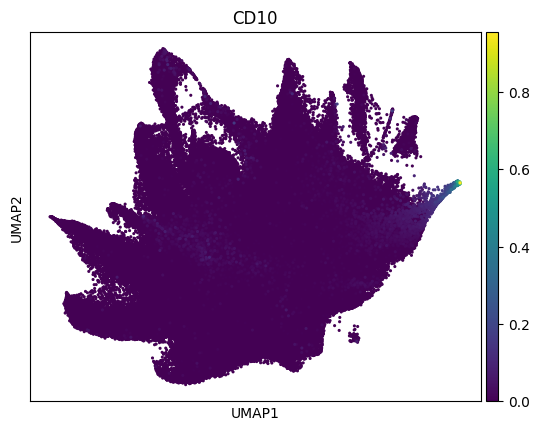

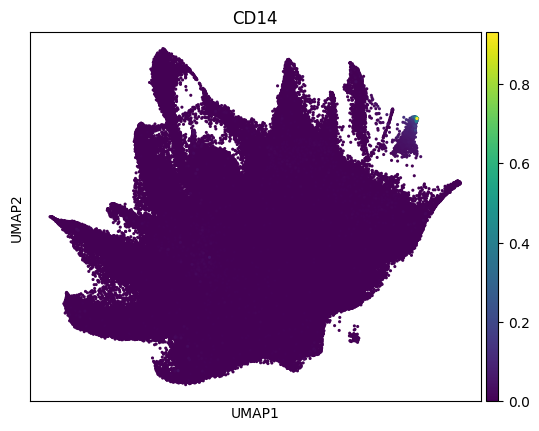

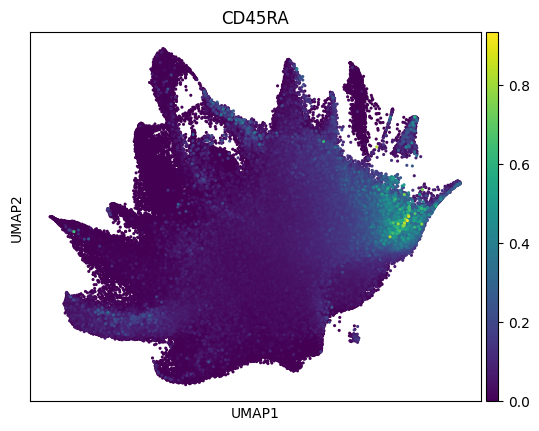

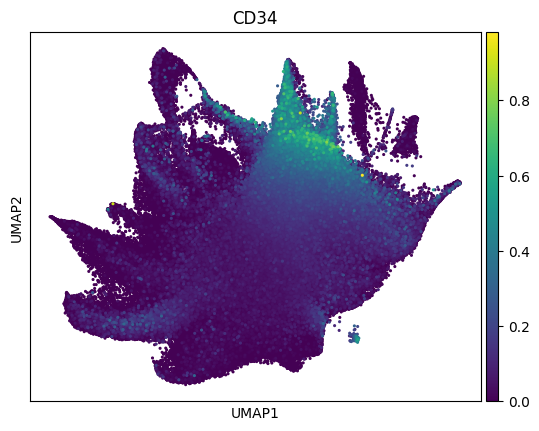

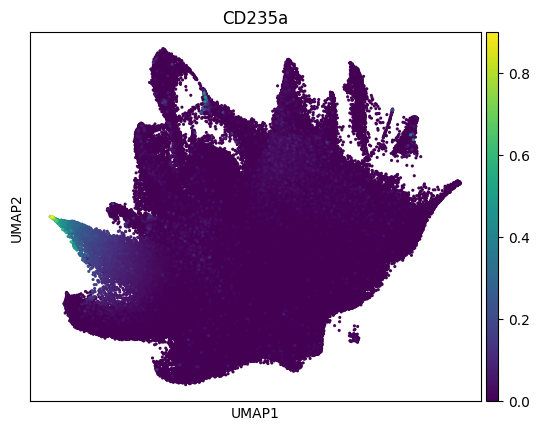

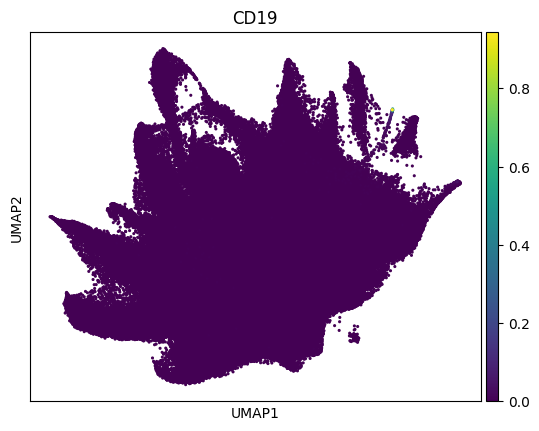

In [189]:
for marker in adata_old_experiments.var.index:
    sc.pl.umap(adata_old_experiments, color=marker, s=20)

In [190]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [191]:
X_scatter = adata_loop2.obs.loc[:, ['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']].values
X_channel = adata_loop2.X

In [192]:
X_clf = np.concatenate([X_channel, X_scatter], axis=1)

In [193]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_clf)), 
    batch_size=4026,
    shuffle=False,
    drop_last=False
)

In [194]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        X_batch = forward_model.target_prediction_model.resc_model.fwd_params(X_batch)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 125/125 [00:06<00:00, 17.99it/s]


In [195]:
ct_predictions = np.concatenate(ct_predictions)
ct_predictions = classes[ct_predictions]

In [196]:
adata_loop2.obs["cell_type"] = ct_predictions
adata_loop2.obs["cell_type"] = adata_loop2.obs["cell_type"].astype("category")

In [197]:
adata_subsample = sc.pp.subsample(adata_loop2, 0.1, copy=True)

In [198]:
sc.pp.neighbors(adata_subsample)
sc.tl.umap(adata_subsample)

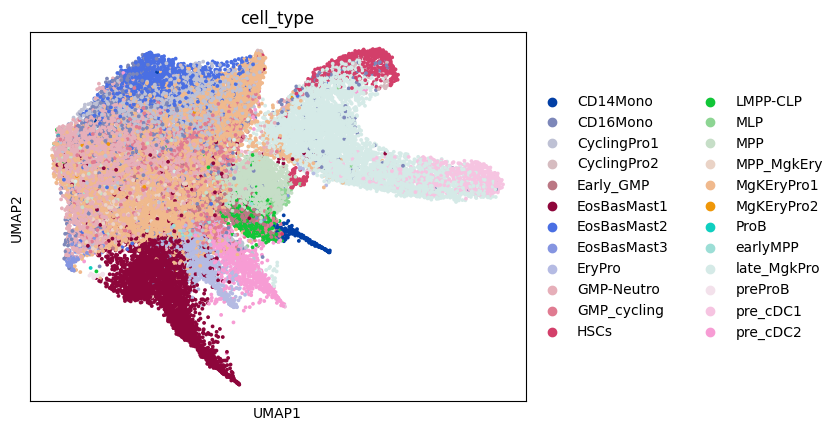

In [263]:
sc.pl.umap(adata_subsample, color="cell_type",s=30)

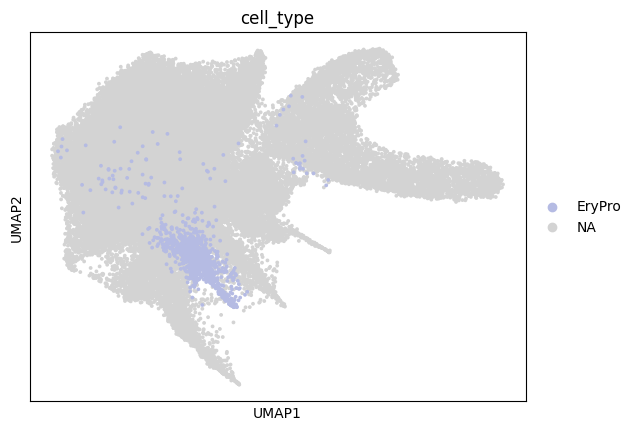

In [200]:
sc.pl.umap(adata_subsample, color="cell_type", groups="EryPro", s=30)

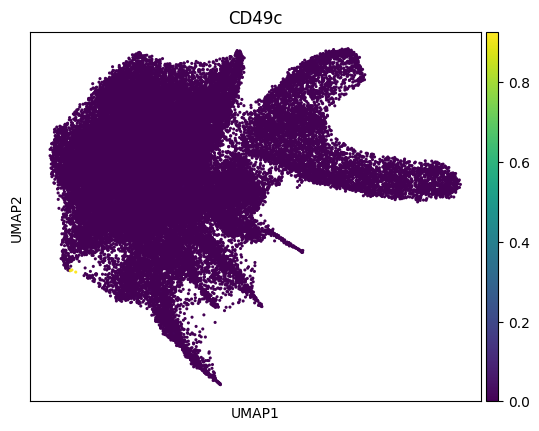

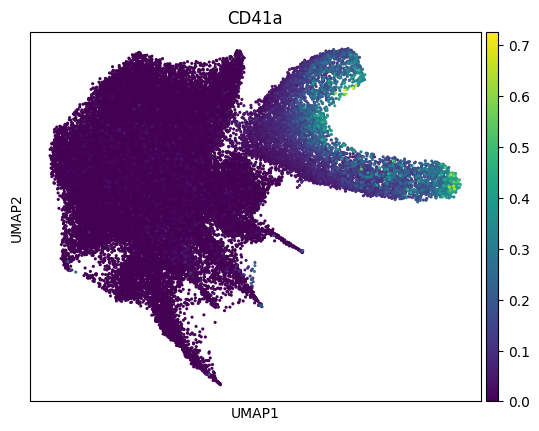

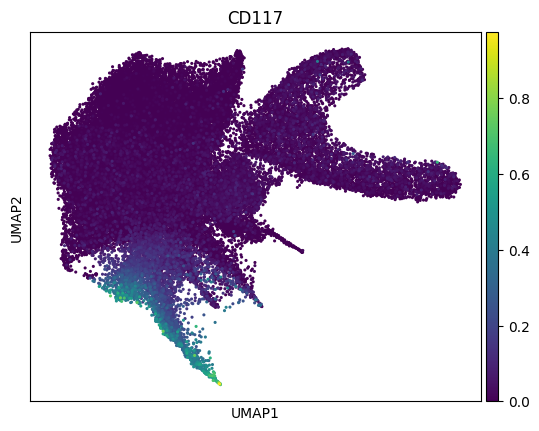

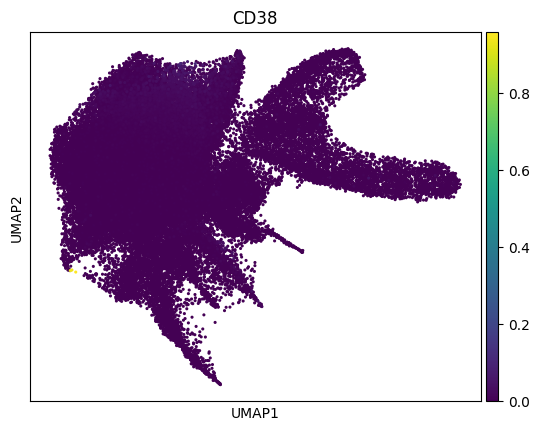

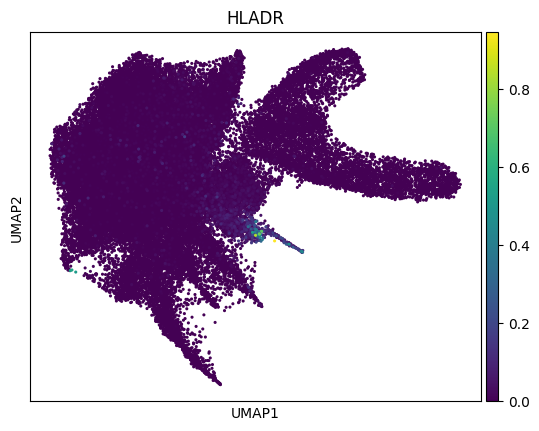

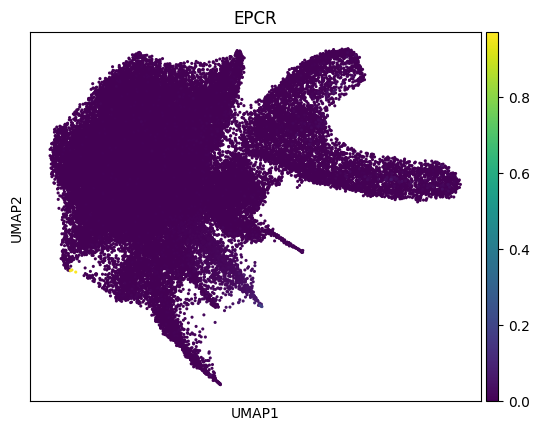

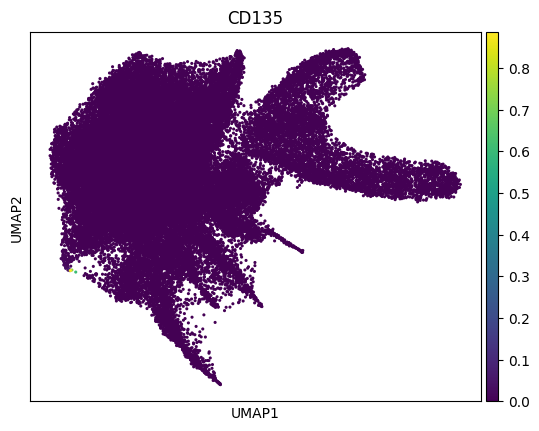

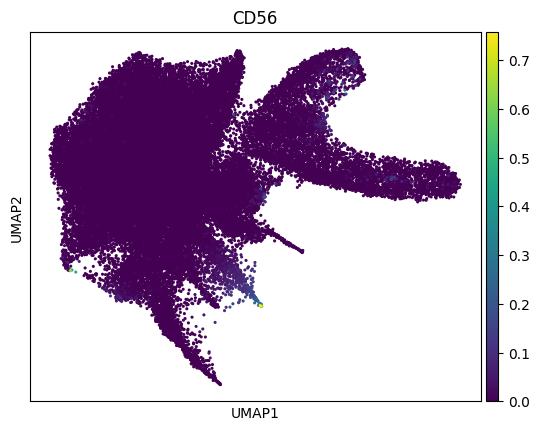

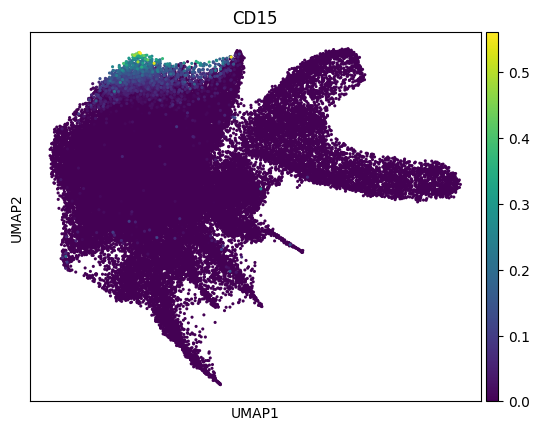

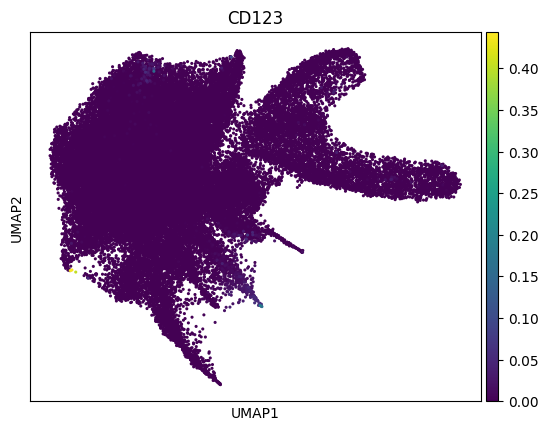

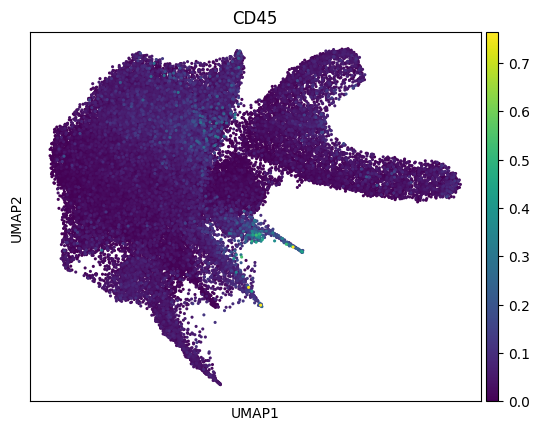

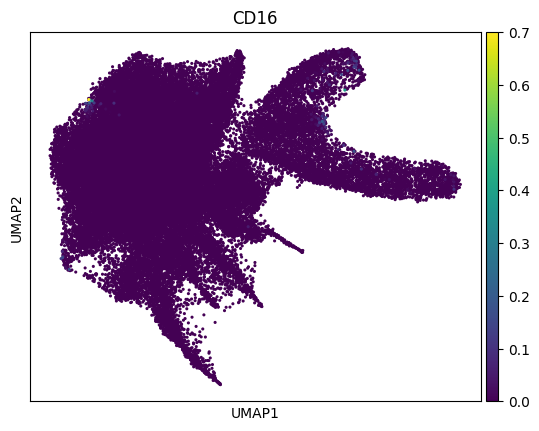

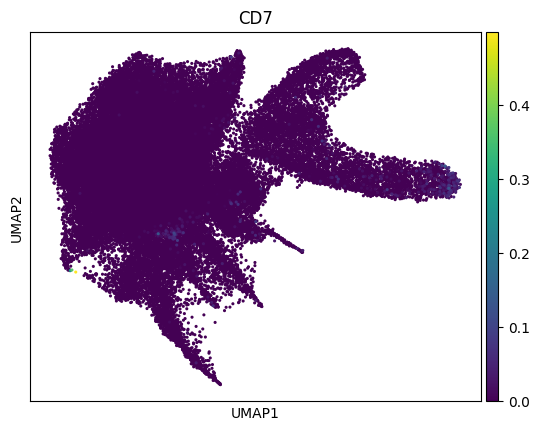

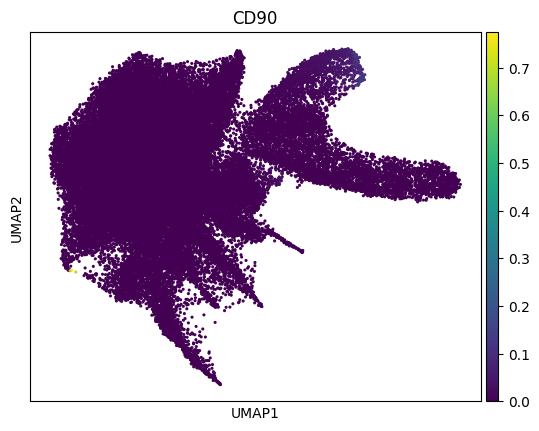

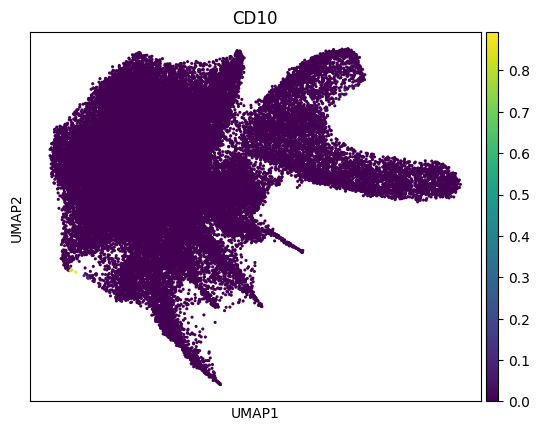

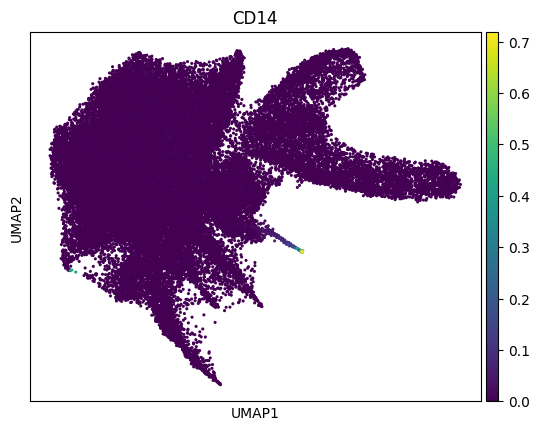

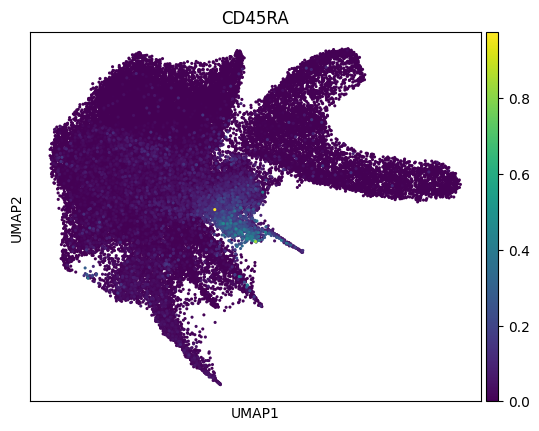

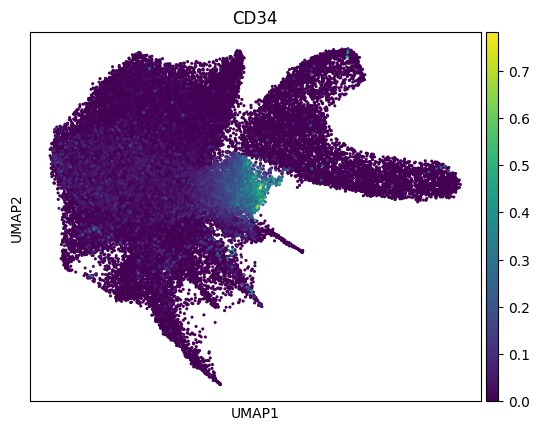

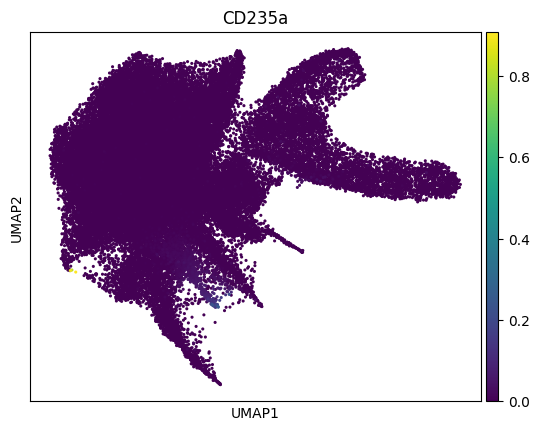

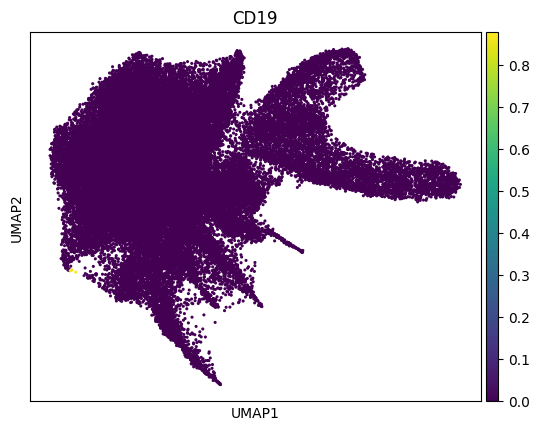

In [201]:
for marker in adata_subsample.var.index:
    sc.pl.umap(adata_subsample, color=marker, s=20)

# Annotate exp number with enriched ct

In [221]:
protocols_loop2 = adata_loop2.obs.loc[:, protocol_cols + ["experiment_number"]] 
protocols_loop2 = protocols_loop2.astype(float)

In [222]:
unique_protocols = pd.DataFrame(np.unique(protocols_loop2, axis=0))
unique_protocols.columns = protocols_loop2.columns

In [223]:
pd.DataFrame(unique_protocols)

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number
0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,19.04,13.24,216.0
1,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,9.26,14.54,217.0
2,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,9.73,16.98,218.0
3,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,19.10,12.00,222.0
4,8.60,2.40,926.60,735.90,0.2,57.80,0.00,0.00,0.0,0.0,20.20,13.10,227.0
5,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.10,13.10,226.0
6,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.40,14.00,224.0
7,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.50,14.00,223.0
8,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.70,17.30,220.0
9,9.20,2.20,997.30,1120.20,0.0,57.20,0.00,0.00,0.1,0.6,20.10,16.40,225.0


In [224]:
unique_protocols = unique_protocols.set_index("experiment_number")

In [225]:
unique_protocols["enriched_ct"] = None

In [256]:
unique_protocols

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,enriched_ct
experiment_number,,,,,,,,,,,,,
216.0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,19.04,13.24,late_mgkPro_low_u
217.0,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,9.26,14.54,late_mgkPro_high_u
218.0,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,9.73,16.98,late_mgkPro_high_u
222.0,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,19.10,12.00,HSC_low_u
227.0,8.60,2.40,926.60,735.90,0.2,57.80,0.00,0.00,0.0,0.0,20.20,13.10,preProB_high_u
226.0,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.10,13.10,preProB_high_u
224.0,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.40,14.00,HSC_high_u
223.0,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.50,14.00,HSC_high_u
220.0,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.70,17.30,EryPro_high_u


In [230]:
unique_protocols.loc[216, "enriched_ct"] = "late_mgkPro_low_u"
unique_protocols.loc[217, "enriched_ct"] = "late_mgkPro_high_u"
unique_protocols.loc[218, "enriched_ct"] = "late_mgkPro_high_u"

unique_protocols.loc[219, "enriched_ct"] = "EryPro_low_u"
unique_protocols.loc[220, "enriched_ct"] = "EryPro_high_u"
unique_protocols.loc[221, "enriched_ct"] = "EryPro_high_u"

unique_protocols.loc[222, "enriched_ct"] = "HSC_low_u"
unique_protocols.loc[223, "enriched_ct"] = "HSC_high_u"
unique_protocols.loc[224, "enriched_ct"] = "HSC_high_u"

unique_protocols.loc[225, "enriched_ct"] = "preProB_low_u"
unique_protocols.loc[226, "enriched_ct"] = "preProB_high_u"
unique_protocols.loc[227, "enriched_ct"] = "preProB_high_u"

unique_protocols.loc[225, "enriched_ct"] = "preProB_low_u"
unique_protocols.loc[226, "enriched_ct"] = "preProB_high_u"
unique_protocols.loc[227, "enriched_ct"] = "preProB_high_u"

In [232]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

In [234]:
map_prot_to_ct

{216.0: 'late_mgkPro_low_u',
 217.0: 'late_mgkPro_high_u',
 218.0: 'late_mgkPro_high_u',
 222.0: 'HSC_low_u',
 227.0: 'preProB_high_u',
 226.0: 'preProB_high_u',
 224.0: 'HSC_high_u',
 223.0: 'HSC_high_u',
 220.0: 'EryPro_high_u',
 225.0: 'preProB_low_u',
 221.0: 'EryPro_high_u',
 219.0: 'EryPro_low_u'}

In [242]:
annot = [map_prot_to_ct[float(exp_number)] for exp_number in  adata_loop2.obs.experiment_number]
adata_loop2.obs["Experiment_type"] = annot

## Plot 

In [245]:
exp_number_ct_prop = {}

In [246]:
for exp_no in np.unique(adata_loop2.obs.experiment_number):
    adata_exp = adata_loop2[adata_loop2.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in classes:
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

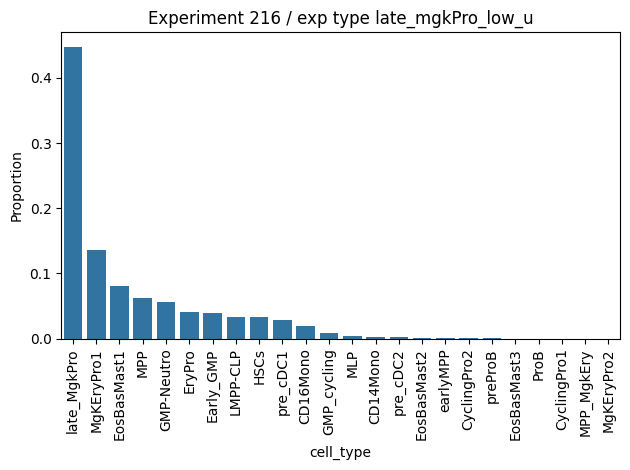

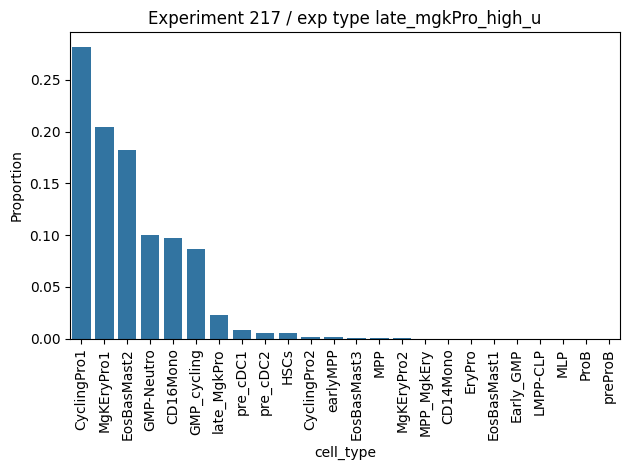

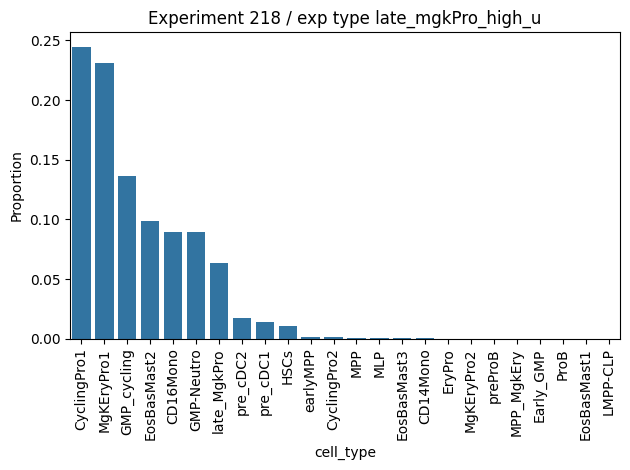

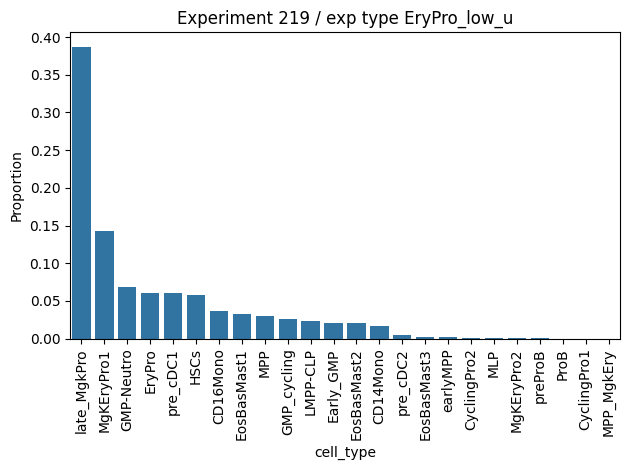

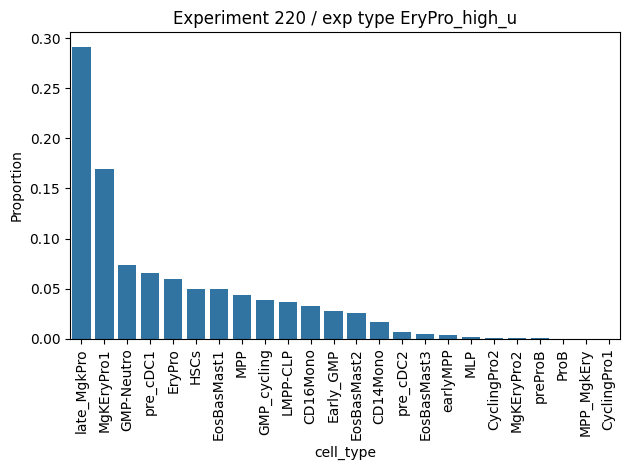

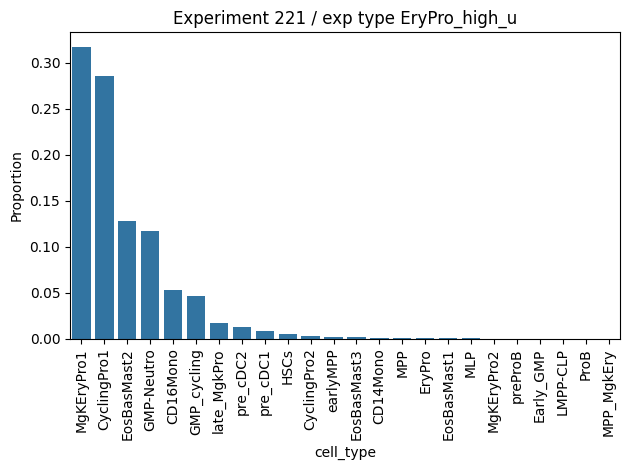

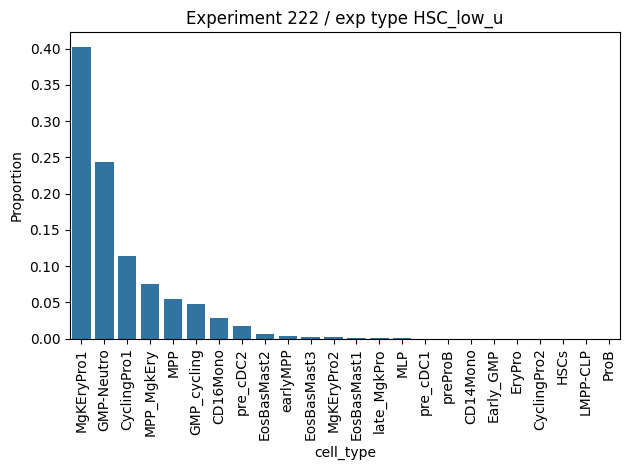

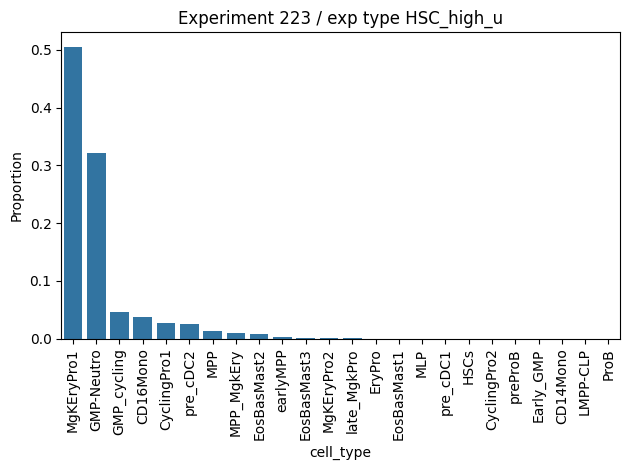

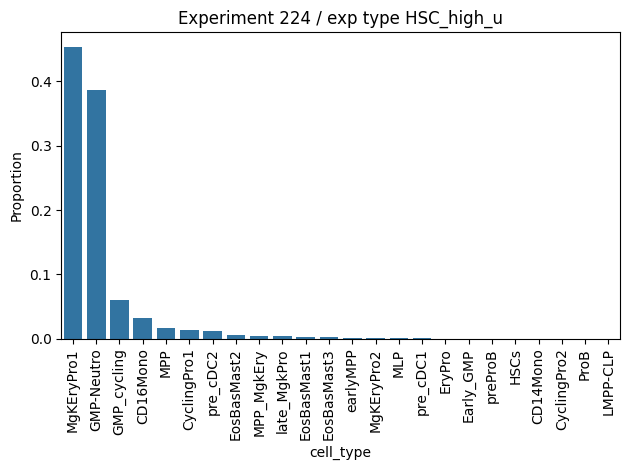

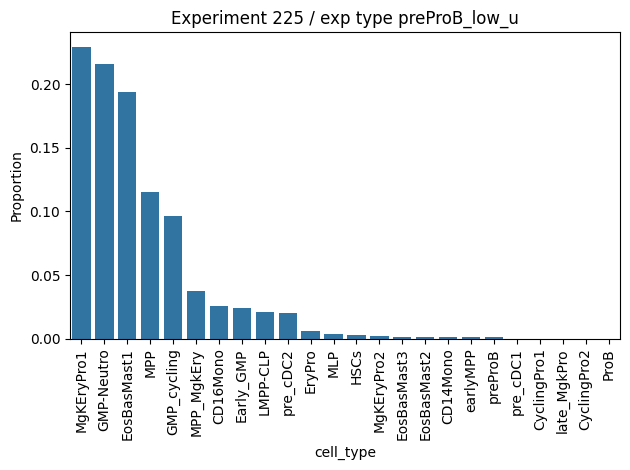

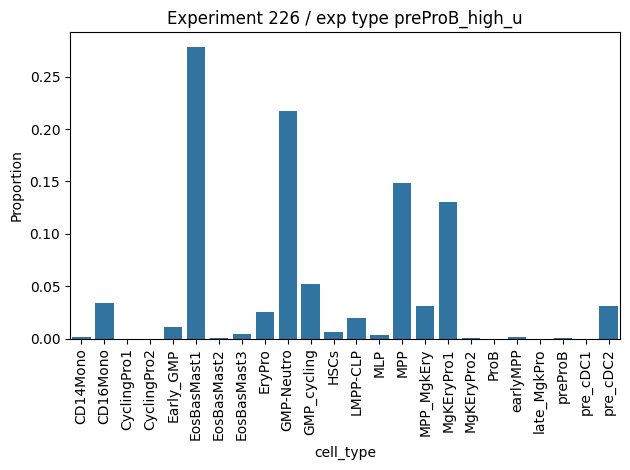

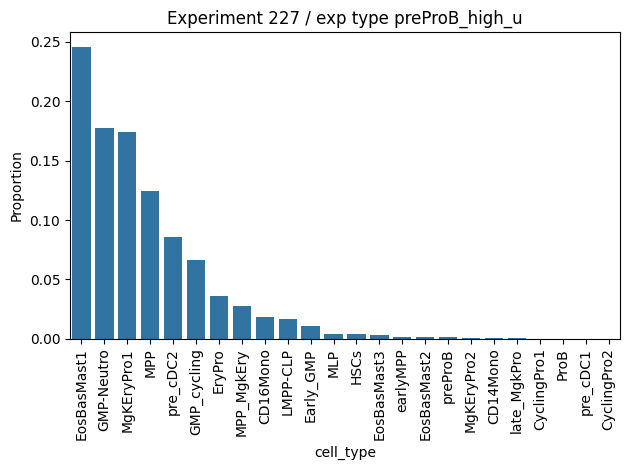

In [247]:
for exp_no in exp_number_ct_prop:
    data = exp_number_ct_prop[exp_no]

    # convert to proportions
    prop = data / data.sum()

    ax = sns.barplot(x=prop.index, y=prop.values)

    plt.xticks(rotation=90)
    plt.ylabel("Proportion")
    plt.title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")

    plt.tight_layout()
    plt.show()

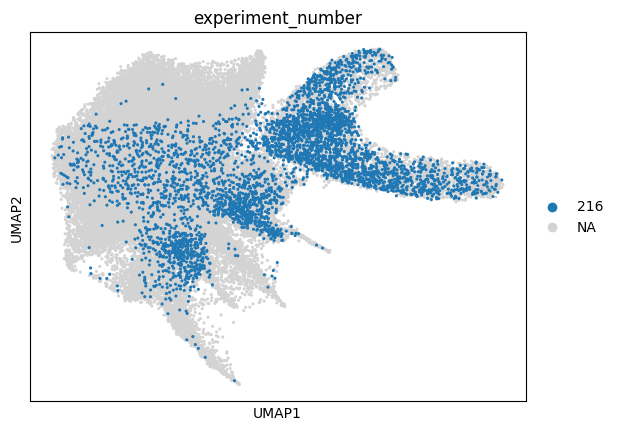

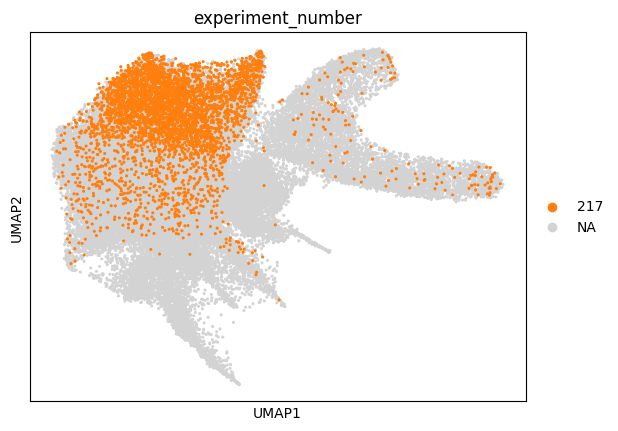

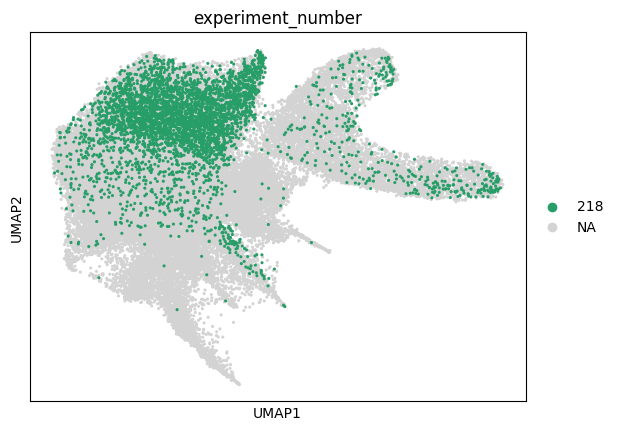

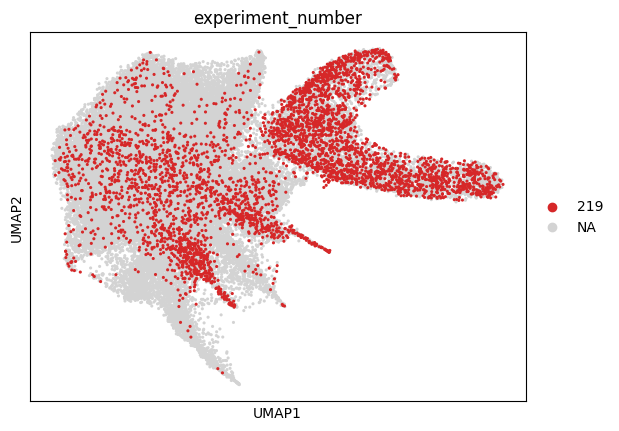

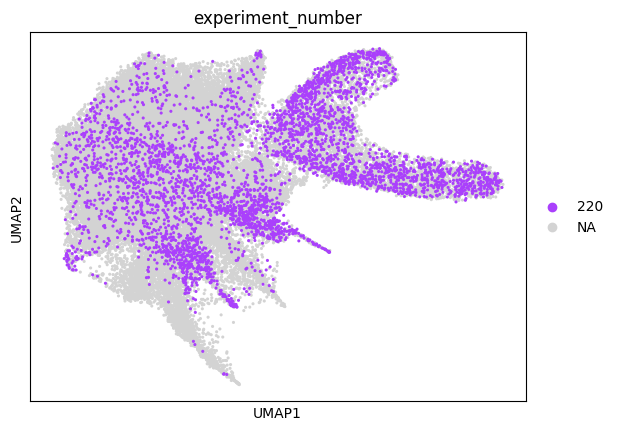

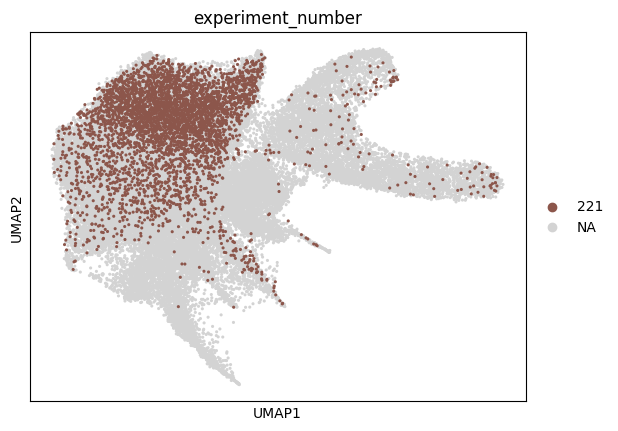

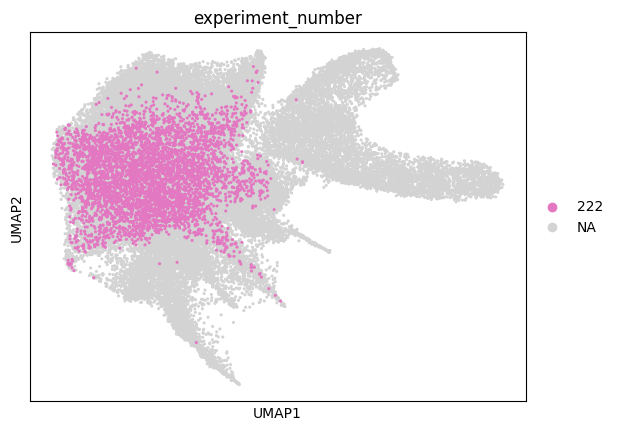

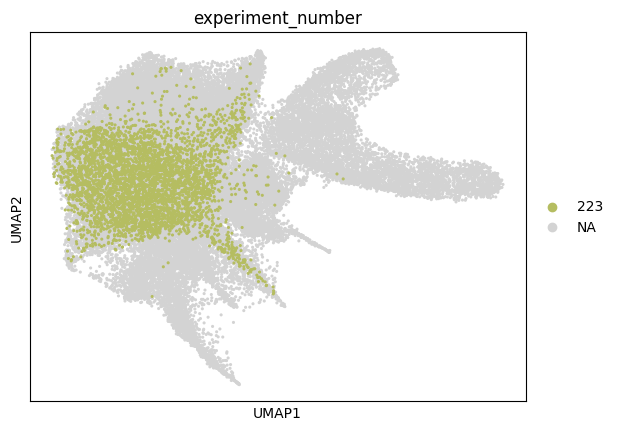

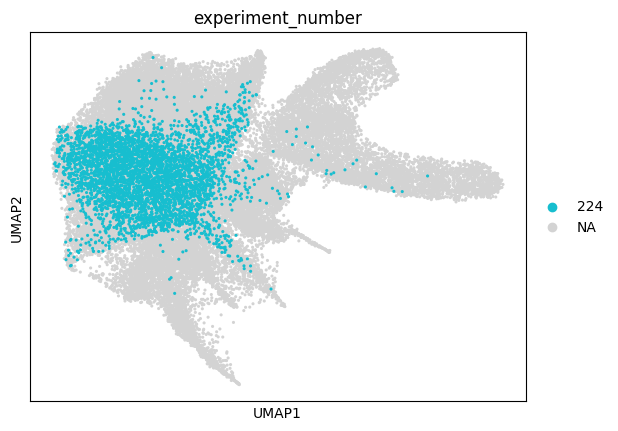

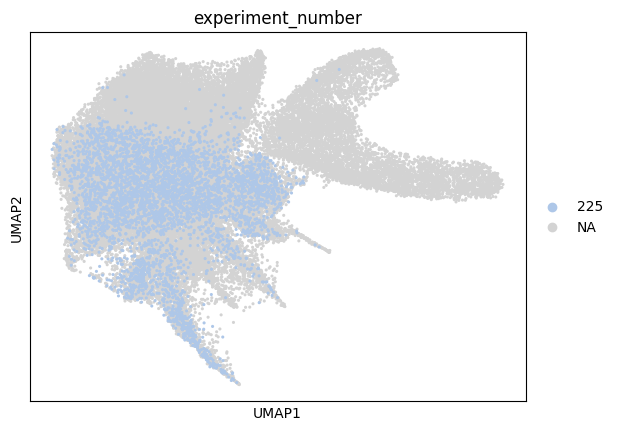

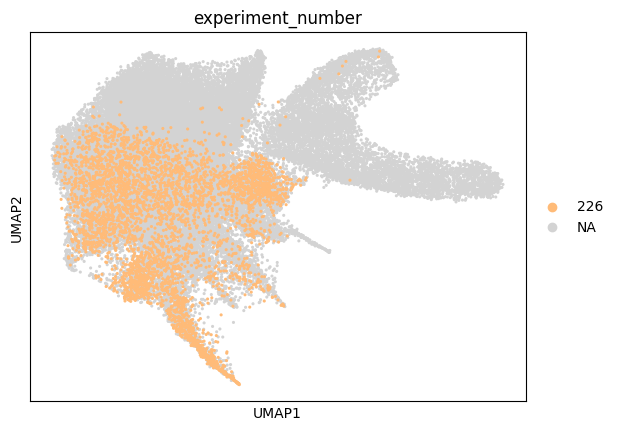

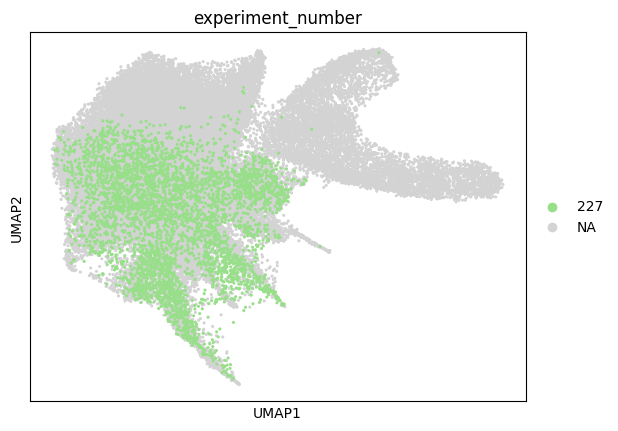

In [255]:
for exp_no in np.unique(adata_subsample.obs.experiment_number):
    sc.pl.umap(adata_subsample, color="experiment_number", s=20, groups=[exp_no])